In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install dependencies


In [9]:
!pip install -q aicspylibczi

# Pick sample z-stack and load the czi file and understand

In [12]:
from aicspylibczi import CziFile
import numpy as np
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/Shraddha-Project/pytorch_fnet/data/tom20/3500001066_100X_20170712_2r-Scene-6-P35-F05.czi"

czi = CziFile(path)
print("Dims:", czi.dims)                      # axis order string, e.g. 'BCZYX'
print("Shape:", czi.size)                     # tuple matching dims order
print("Dimension sizes:", czi.get_dims_shape())  # dict mapping each axis -> range

# channel names live in the metadata, not a direct attribute
meta = czi.meta   # ElementTree of the CZI XML metadata
channels = [c.get("Name") for c in meta.iter("Channel") if c.get("Name")]
print("Channels:", channels)

Dims: BSCZYX
Shape: (1, 1, 7, 65, 624, 924)
Dimension sizes: [{'X': (0, 924), 'Y': (0, 624), 'Z': (0, 65), 'C': (0, 7), 'S': (0, 1), 'B': (0, 1)}]
Channels: ['CMDRP_1', 'CMDRP', 'EGFP_1', 'EGFP', 'H3342_2', 'H3342_3', 'Bright_10X', 'Bright_100X', 'Black_Reference', 'CMDRP_1', 'CMDRP', 'EGFP_1', 'EGFP', 'H3342_2', 'H3342_3', 'Bright_100X', 'CMDRP_1', 'CMDRP', 'EGFP_1', 'EGFP', 'H3342_2', 'H3342_3', 'Bright_100X']


Mapping seven channels (0-indexed) to the paper:

* 0 — CMDRP_1: CellMask membrane (the 638 nm / far-red dye, "CMDR" = CellMask
Deep Red). The _1 is a processed/duplicate variant.
* 1 — CMDRP: CellMask membrane, the primary version of the same channel.
* 2 — EGFP_1: the EGFP-tagged structure — for this dataset, TOM20 = mitochondria (488 nm). Processed variant.
* 3 — EGFP: the EGFP TOM20 fluorescence, primary version. This is the fluorescence target.
* 4 — H3342_2: Hoechst 33342 = DNA (405 nm). The paper calls this the NucBlue/Hoechst DNA channel.
* 5 — H3342_3: Hoechst/DNA, another variant.
* 6 — Bright_100X: transmitted-light brightfield, 100× objective. This is the model input.

# Visualize all 7 channel z-stack middle image

channels: 7  z-stack: 65


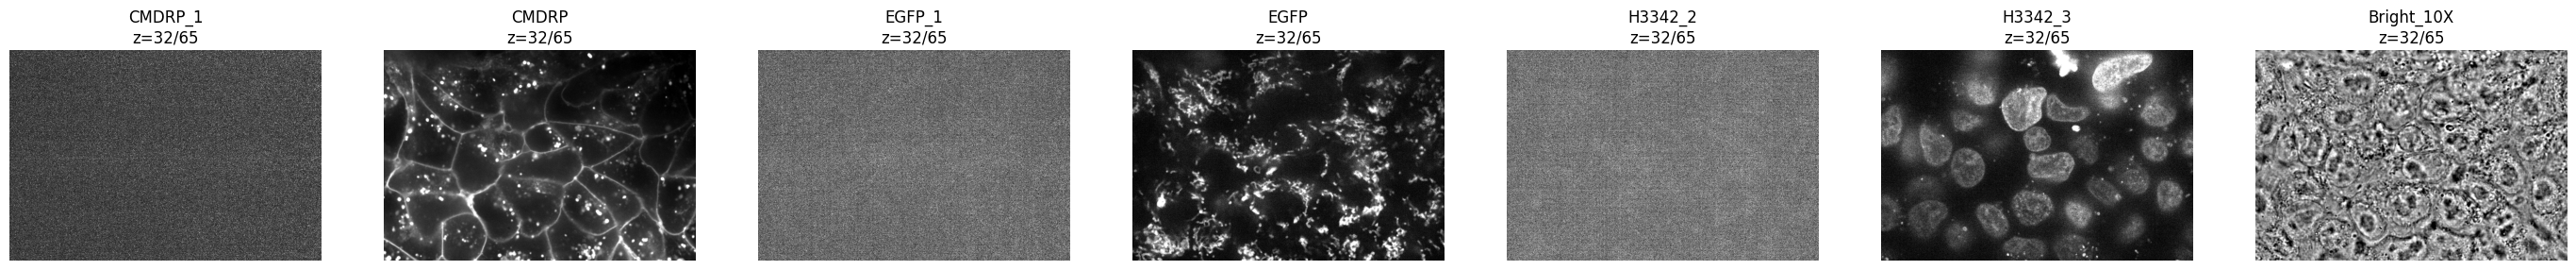

In [35]:
dims_dict = czi.get_dims_shape()[0]          # e.g. {'C': (0, 7), 'Z': (0, n), ...}
n_channels = dims_dict['C'][1] - dims_dict['C'][0]
n_z        = dims_dict['Z'][1] - dims_dict['Z'][0]
z_mid      = n_z // 2

# channel names from metadata (may be empty/partial — falls back to index)
channels = [c.get("Name") for c in czi.meta.iter("Channel") if c.get("Name")]

print("channels:", n_channels, " z-stack:", n_z)

def read_channel(c):
    arr, _ = czi.read_image(C=c)
    return np.squeeze(arr)                   # -> (Z, Y, X)

plt.figure(figsize=[5 * n_channels, 5])
for c in range(n_channels):
    vol = read_channel(c)
    sl = vol[z_mid] if vol.ndim == 3 else vol
    lo, hi = np.percentile(sl, [1, 99])      # contrast stretch for 16-bit data
    plt.subplot(1, n_channels, c + 1)
    plt.imshow(sl, cmap="gray", vmin=lo, vmax=hi)
    name = channels[c] if c < len(channels) else f"channel {c}"
    plt.title(f"{name}\nz={z_mid}/{n_z}")
    plt.axis("off")
plt.show()

# Channel starting from 0 to 6, our input z-stack is channel 6th and output z-stack is channel 3rd

shape: (1, 1, 7, 65, 624, 924)


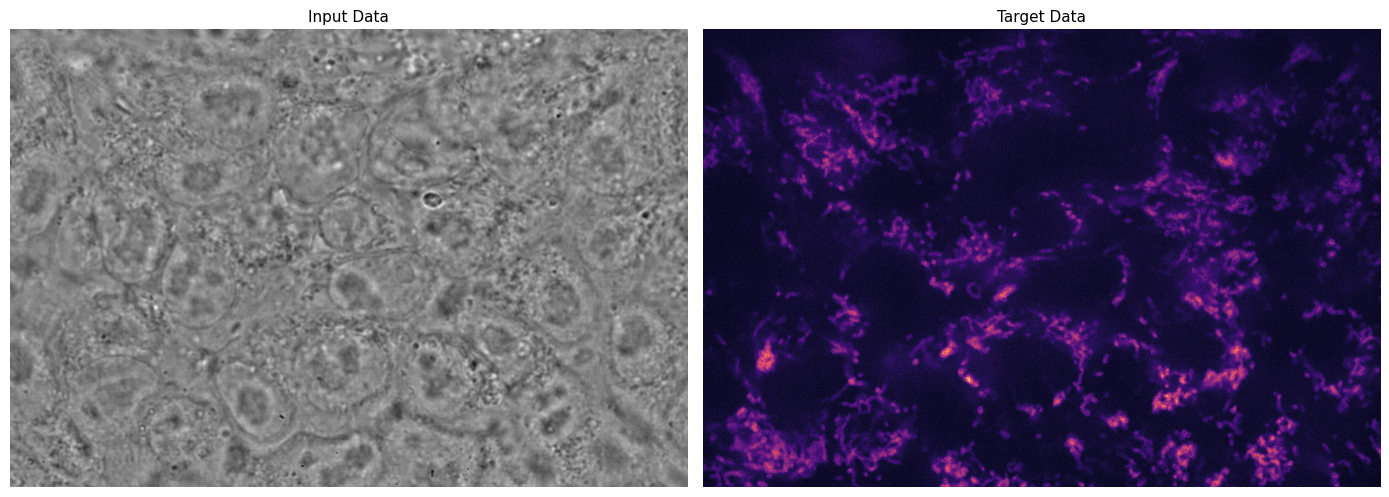

In [18]:
from aicspylibczi import CziFile
import numpy as np
import matplotlib.pyplot as plt

def mid_slice(vol):
    vol = np.squeeze(vol)
    if vol.ndim == 3:
        return vol[vol.shape[0] // 2]
    return vol

path = "/content/drive/MyDrive/Shraddha-Project/pytorch_fnet/data/tom20/3500001066_100X_20170712_2r-Scene-6-P35-F05.czi"

czi = CziFile(path)

def read_channel(c):
    arr, _ = czi.read_image(C=c)
    return np.squeeze(arr)                    # (Z, Y, X)

print("shape:", czi.size)

input_data = mid_slice(read_channel(6))
target_data = mid_slice(read_channel(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(input_data, cmap='gray')
axes[0].set_title('Input Data', fontsize=11)
axes[0].axis('off')

axes[1].imshow(target_data, cmap='magma')
axes[1].set_title('Target Data', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Check data reshape is 2 ways,
* Crop the input image - we loose information
* Resize the input image - try to preserve the full information pattern

crop shapes: (65, 256, 256) (65, 256, 256)
resize shapes: (65, 256, 256) (65, 256, 256)


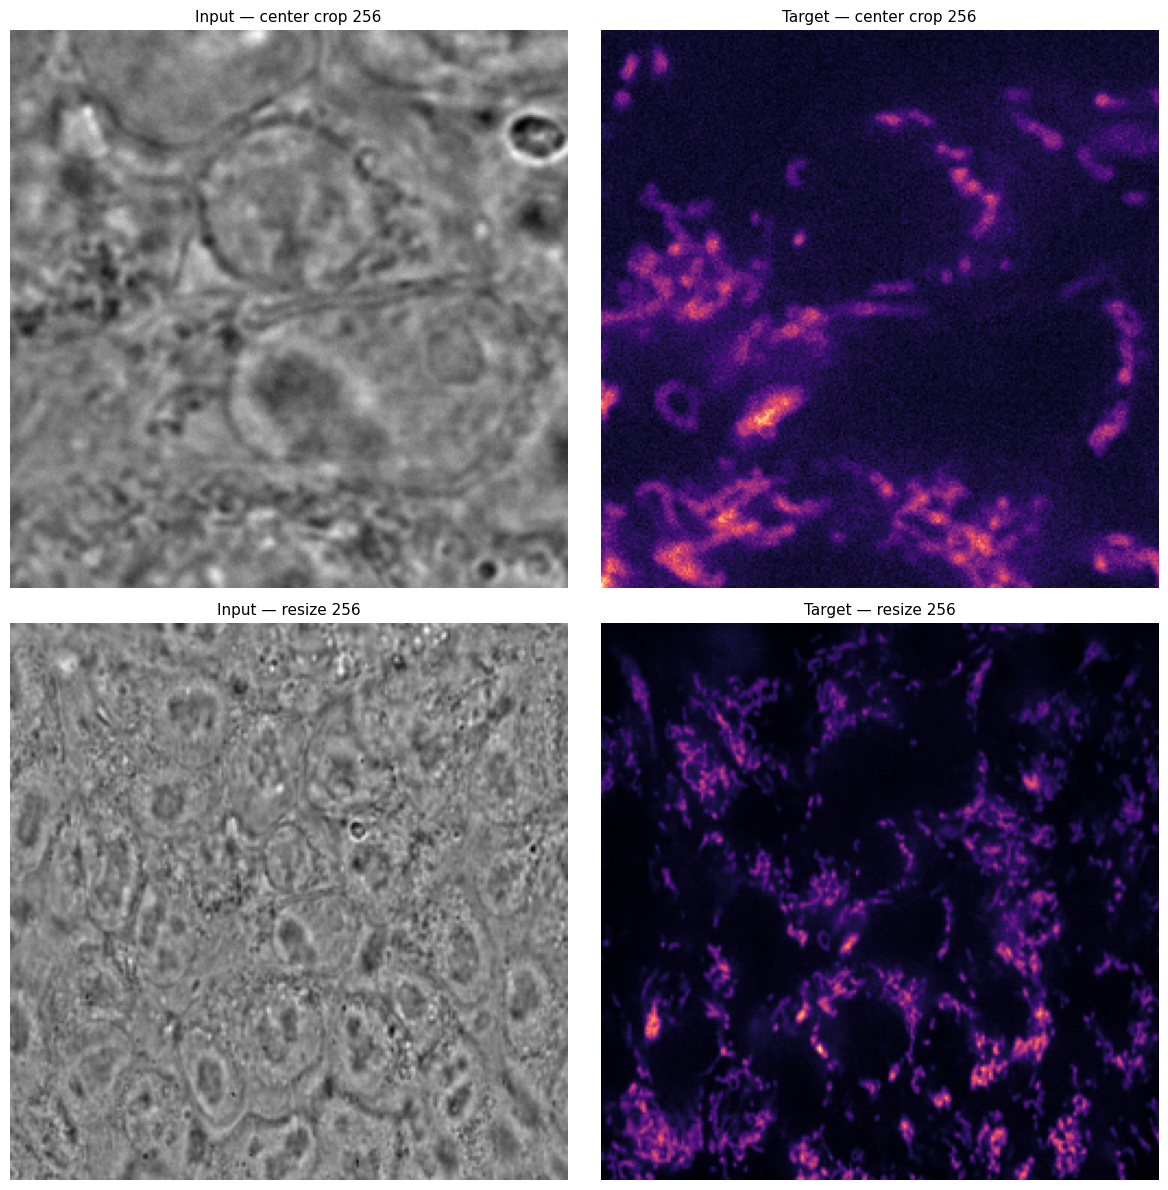

In [24]:
from skimage.transform import resize


def crop_volume(vol, size=256, y_start=None, x_start=None,
                y_end=None, x_end=None):
    """
    Crop a (Z, Y, X) volume in the spatial (Y, X) dims. Z kept in full.
    Default = centered size x size crop. Override with explicit pixel bounds:
      *_start + size      -> size crop from that corner
      *_start AND *_end   -> exact [start:end] window
    Cropping is plain NumPy slicing (the standard idiom; no library function
    does start/end windows better).
    """
    z, y, x = vol.shape

    if y_end is not None:
        y0 = y_start if y_start is not None else 0
        y1 = y_end
    elif y_start is not None:
        y0, y1 = y_start, y_start + size
    else:
        y0 = (y - size) // 2
        y1 = y0 + size

    if x_end is not None:
        x0 = x_start if x_start is not None else 0
        x1 = x_end
    elif x_start is not None:
        x0, x1 = x_start, x_start + size
    else:
        x0 = (x - size) // 2
        x1 = x0 + size

    if y0 < 0 or x0 < 0 or y1 > y or x1 > x:
        raise ValueError(f"Crop bounds Y[{y0}:{y1}] X[{x0}:{x1}] "
                         f"exceed volume (Y={y}, X={x}).")

    return vol[:, y0:y1, x0:x1]


def resize_volume(vol, size=256, order=1):
    """
    Resize a (Z, Y, X) volume's spatial dims to size x size via
    skimage.transform.resize. Z left unchanged. preserve_range=True keeps
    raw intensities (no 0-1 rescaling before z-scoring).
    order: 0=nearest, 1=linear, 3=cubic.
    """
    z, y, x = vol.shape
    return resize(vol, (z, size, size), order=order,
                  preserve_range=True, anti_aliasing=True)


# --- apply to a single channel at a time ---
input_vol  = read_channel(6)    # (Z, Y, X) brightfield
target_vol = read_channel(3)    # (Z, Y, X) EGFP

# crop (centered by default)
input_crop  = crop_volume(input_vol,  size=256)
target_crop = crop_volume(target_vol, size=256)
print("crop shapes:", input_crop.shape, target_crop.shape)

# resize (whole field of view -> 256x256)
input_resz  = resize_volume(input_vol,  size=256, order=1)
target_resz = resize_volume(target_vol, size=256, order=3)  # cubic for target
print("resize shapes:", input_resz.shape, target_resz.shape)

# --- visualize: mid-slice of cropped vs resized, both channels ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(mid_slice(input_crop),  cmap='gray')
axes[0, 0].set_title('Input — center crop 256', fontsize=11); axes[0, 0].axis('off')
axes[0, 1].imshow(mid_slice(target_crop), cmap='magma')
axes[0, 1].set_title('Target — center crop 256', fontsize=11); axes[0, 1].axis('off')

axes[1, 0].imshow(mid_slice(input_resz),  cmap='gray')
axes[1, 0].set_title('Input — resize 256', fontsize=11); axes[1, 0].axis('off')
axes[1, 1].imshow(mid_slice(target_resz), cmap='magma')
axes[1, 1].set_title('Target — resize 256', fontsize=11); axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Resize the image wihtout changing the aspect ratio

resize shapes: (65, 173, 256) (65, 173, 256)


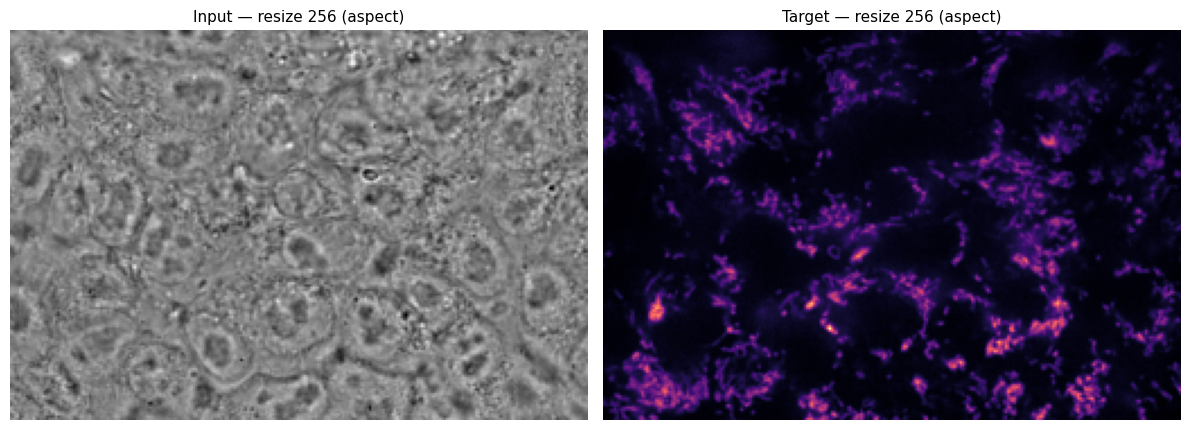

In [27]:
def resize_aspect_volume(vol, size=256, order=1):
    """
    Resize a (Z, Y, X) volume so the LARGER spatial dim becomes `size`,
    preserving aspect ratio. Smaller dim scales proportionally (no padding).
    Z unchanged. order: 0=nearest, 1=linear, 3=cubic.
    """
    z, y, x = vol.shape
    scale = size / max(y, x)
    new_y = max(1, round(y * scale))
    new_x = max(1, round(x * scale))
    return resize(vol, (z, new_y, new_x), order=order,
                  preserve_range=True, anti_aliasing=True)


input_resz_ar  = resize_aspect_volume(input_vol,  size=256, order=1)
target_resz_ar = resize_aspect_volume(target_vol, size=256, order=3)
print("resize shapes:", input_resz_ar.shape, target_resz_ar.shape)

# --- visualize: mid-slice of aspect-ratio resize, both channels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mid_slice(input_resz_ar),  cmap='gray')
axes[0].set_title('Input — resize 256 (aspect)', fontsize=11); axes[0].axis('off')
axes[1].imshow(mid_slice(target_resz_ar), cmap='magma')
axes[1].set_title('Target — resize 256 (aspect)', fontsize=11); axes[1].axis('off')
plt.tight_layout()
plt.show()

# Resize the image wihtout changing the aspect ratio and also pad the image with 0 to generarte perfect 256x256 image

pad shapes: (65, 256, 256) (65, 256, 256)


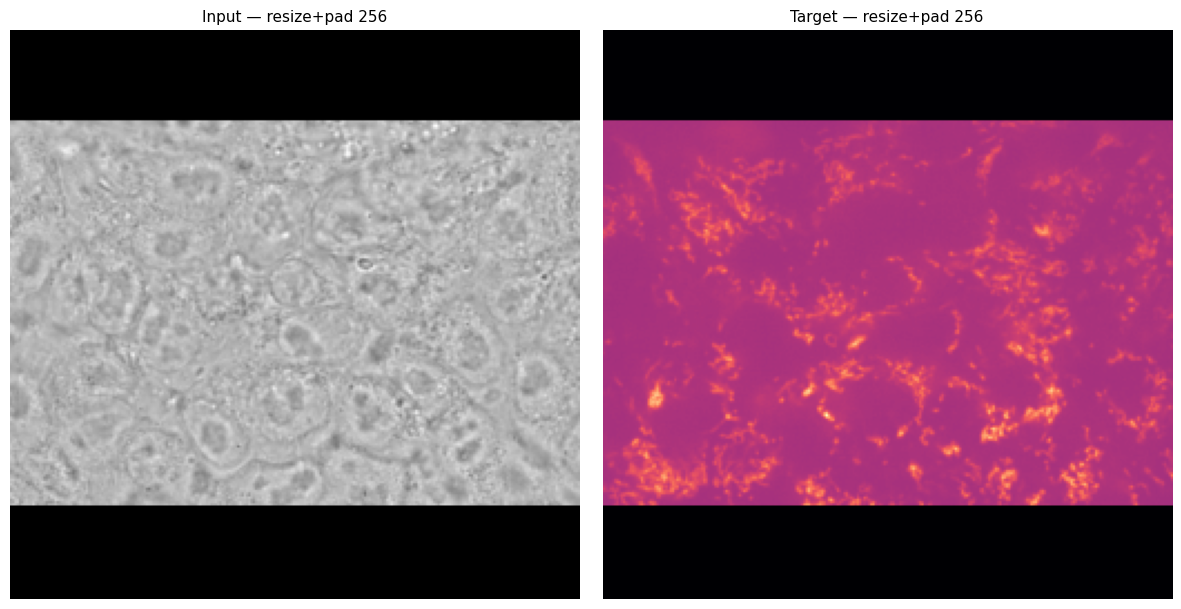

In [29]:
def resize_pad_volume(vol, size=256, order=1):
    """
    Resize a (Z, Y, X) volume so the LARGER spatial dim becomes `size`,
    preserving aspect ratio, then zero-pad the smaller dim up to `size`.
    Result spatial dims = size x size. Z unchanged.
    order: 0=nearest, 1=linear, 3=cubic.
    """
    z, y, x = vol.shape
    scale = size / max(y, x)
    new_y = max(1, round(y * scale))
    new_x = max(1, round(x * scale))

    resized = resize(vol, (z, new_y, new_x), order=order,
                     preserve_range=True, anti_aliasing=True)

    pad_y = size - new_y
    pad_x = size - new_x
    y0 = pad_y // 2
    x0 = pad_x // 2
    pad_width = ((0, 0),
                 (y0, pad_y - y0),
                 (x0, pad_x - x0))

    return np.pad(resized, pad_width, mode='constant', constant_values=0)


input_pad  = resize_pad_volume(input_vol,  size=256, order=1)
target_pad = resize_pad_volume(target_vol, size=256, order=3)
print("pad shapes:", input_pad.shape, target_pad.shape)

# --- visualize: mid-slice of resize+pad, both channels ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mid_slice(input_pad),  cmap='gray')
axes[0].set_title('Input — resize+pad 256', fontsize=11); axes[0].axis('off')
axes[1].imshow(mid_slice(target_pad), cmap='magma')
axes[1].set_title('Target — resize+pad 256', fontsize=11); axes[1].axis('off')
plt.tight_layout()
plt.show()

# Data loader

In [47]:
import os
import glob
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from aicspylibczi import CziFile
from skimage.transform import resize


class CziPairedDataset:
    """
    Load all .czi files in a folder (multithreaded), resize+pad every z-slice
    to size x size, and build paired input/target stacks.

    Each z-slice becomes one (1, size, size) sample. Input and target stay
    index-aligned: self.inputs[i] corresponds to self.targets[i].

    Final arrays:
        inputs  : (N, 1, size, size)
        targets : (N, 1, size, size)
    where N = sum over files of (#z-slices).
    """

    def __init__(self, folder, input_channel=6, target_channel=3,
                 size=256, input_order=1, target_order=3, max_workers=None):
        self.folder = folder
        self.input_channel = input_channel
        self.target_channel = target_channel
        self.size = size
        self.input_order = input_order
        self.target_order = target_order
        self.max_workers = max_workers      # None -> ThreadPool default

        self.files = sorted(glob.glob(os.path.join(folder, "*.czi")))
        if not self.files:
            raise FileNotFoundError(f"No .czi files found in {folder}")

        self.index = []          # list of (file_path, z) per sample
        self.inputs = None       # (N, 1, size, size)
        self.targets = None      # (N, 1, size, size)

    # ---------- helpers ----------
    @staticmethod
    def _read_channel(czi, c):
        arr, _ = czi.read_image(C=c)
        return np.squeeze(arr)               # (Z, Y, X)

    def _resize_pad_volume(self, vol, order):
        """Resize larger spatial dim to `size`, pad smaller dim with zeros.
        Preserves input dtype."""
        if vol.ndim == 2:
            vol = vol[None]                  # promote to (1, Y, X)
        z, y, x = vol.shape
        in_dtype = vol.dtype

        scale = self.size / max(y, x)
        new_y = max(1, round(y * scale))
        new_x = max(1, round(x * scale))

        resized = resize(vol, (z, new_y, new_x), order=order,
                         preserve_range=True, anti_aliasing=True)

        pad_y = self.size - new_y
        pad_x = self.size - new_x
        y0, x0 = pad_y // 2, pad_x // 2
        pad_width = ((0, 0), (y0, pad_y - y0), (x0, pad_x - x0))
        padded = np.pad(resized, pad_width, mode='constant', constant_values=0)

        if np.issubdtype(in_dtype, np.integer):
            padded = np.rint(padded)
        return padded.astype(in_dtype)

    # ---------- per-file worker ----------
    def _process_file(self, path):
        """Read + resize+pad one file. Returns (in_rp, tgt_rp) volumes."""
        czi = CziFile(path)
        in_vol  = self._read_channel(czi, self.input_channel)    # (Z, Y, X)
        tgt_vol = self._read_channel(czi, self.target_channel)

        in_rp  = self._resize_pad_volume(in_vol,  self.input_order)   # (Z, size, size)
        tgt_rp = self._resize_pad_volume(tgt_vol, self.target_order)
        return in_rp, tgt_rp

    # ---------- main loader ----------
    def load(self, verbose=True):
        results = [None] * len(self.files)   # keep file order deterministic

        with ThreadPoolExecutor(max_workers=self.max_workers) as ex:
            future_to_fi = {ex.submit(self._process_file, path): fi
                            for fi, path in enumerate(self.files)}
            done = 0
            for fut in as_completed(future_to_fi):
                fi = future_to_fi[fut]
                in_rp, tgt_rp = fut.result()         # propagates worker errors
                results[fi] = (in_rp, tgt_rp)
                done += 1
                if verbose:
                    print(f"[{done}/{len(self.files)}] "
                          f"{os.path.basename(self.files[fi])} "
                          f"-> {in_rp.shape[0]} slices")

        # assemble in original file order so index stays meaningful
        inputs, targets = [], []
        for fi, path in enumerate(self.files):
            in_rp, tgt_rp = results[fi]
            n_z = in_rp.shape[0]
            for z in range(n_z):
                inputs.append(in_rp[z][None])        # (1, size, size)
                targets.append(tgt_rp[z][None])
                self.index.append((path, z))

        self.inputs  = np.stack(inputs)              # (N, 1, size, size)
        self.targets = np.stack(targets)
        if verbose:
            print("Final shapes:", self.inputs.shape, self.targets.shape)
        return self.inputs, self.targets

    # ---------- utilities ----------
    def __len__(self):
        return 0 if self.inputs is None else self.inputs.shape[0]

    def shuffle(self, seed=None):
        """Shuffle samples while keeping input[i] <-> target[i] paired."""
        rng = np.random.default_rng(seed)
        perm = rng.permutation(len(self))
        self.inputs  = self.inputs[perm]
        self.targets = self.targets[perm]
        self.index   = [self.index[i] for i in perm]
        return perm

In [33]:
folder = "/content/drive/MyDrive/Shraddha-Project/pytorch_fnet/data/tom20"

ds = CziPairedDataset(folder, input_channel=6, target_channel=3, size=256)
inputs, targets = ds.load()
print("dataset size:", len(ds))            # expect ~5200 (80 files x 65 z)
print("dtypes:", inputs.dtype, targets.dtype)

# shuffle without breaking pairing
ds.shuffle(seed=42)

[1/80] 3500000961_100X_20170609_1-Scene-19-P19-E06.czi -> 65 slices
[2/80] 3500000968_100X_20170612_2-Scene-26-P55-F07.czi -> 65 slices
[3/80] 3500000964_100X_20170612_3-Scene-2-P12-E05.czi -> 65 slices
[4/80] 3500000959_100X_20170609_7-Scene-01-P31-E07.czi -> 65 slices
[5/80] 3500000961_100X_20170609_1-Scene-01-P1-E04.czi -> 65 slices
[6/80] 3500000961_100X_20170609_1-Scene-15-P15-E06.czi -> 65 slices
[7/80] 3500000959_100X_20170609_7-Scene-07-P37-E07.czi -> 65 slices
[8/80] 3500000961_100X_20170609_3-Scene-08-P60-F07.czi -> 65 slices
[9/80] 3500000968_100X_20170612_1-Scene-28-P28-E06.czi -> 65 slices
[10/80] 3500000961_100X_20170609_2-Scene-09-P30-E07.czi -> 65 slices
[11/80] 3500000968_100X_20170612_2-Scene-09-P37-E08.czi -> 65 slices
[12/80] 3500000969_100X_20170613_1-Scene-07-P7-E04.czi -> 65 slices
[13/80] 3500000969_100X_20170613_1-Scene-14-P14-E06.czi -> 65 slices
[14/80] 3500000969_100X_20170613_2-Scene-09-P28-E08.czi -> 65 slices
[15/80] 3500000972_100X_20170614_1-Scene-2-P2-

array([ 234, 2507, 3422, ..., 2189, 4802, 1672])

sample 395: 3500001057_100X_20170712_e1-Scene-08-P22-E07.czi z=32


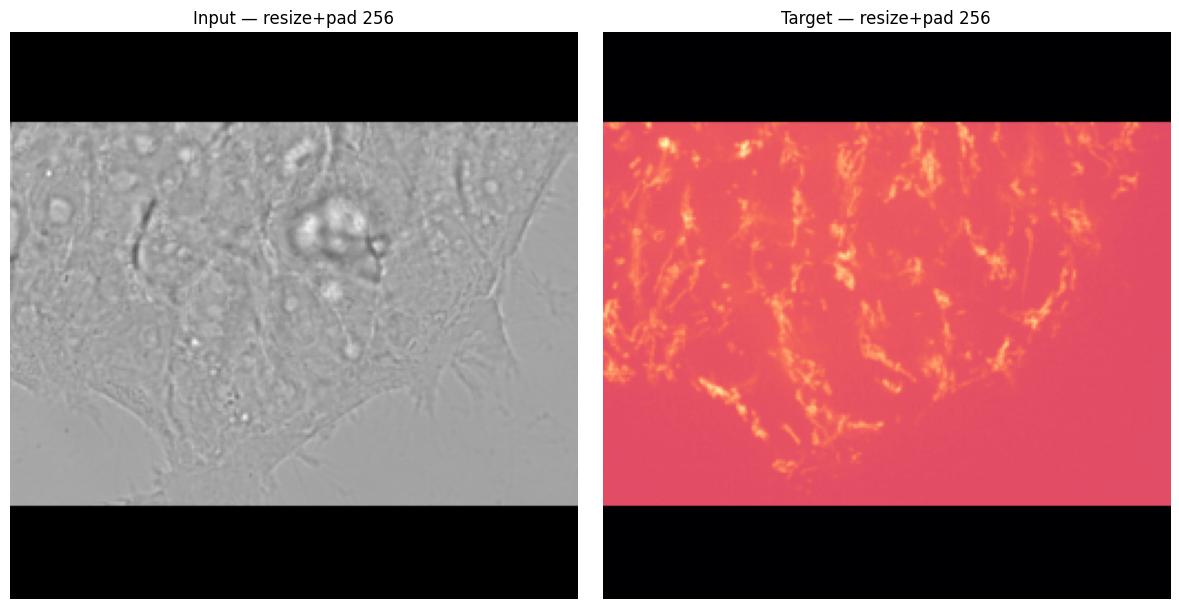

In [34]:
i = np.random.randint(len(ds))
src_file, z = ds.index[i]
print(f"sample {i}: {os.path.basename(src_file)} z={z}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ds.inputs[i, 0],  cmap='gray')
axes[0].set_title('Input — resize+pad 256');  axes[0].axis('off')
axes[1].imshow(ds.targets[i, 0], cmap='magma')
axes[1].set_title('Target — resize+pad 256'); axes[1].axis('off')
plt.tight_layout()
plt.show()

NOte: U-Net adapted for image-to-image task (brightfield input → EGFP target), plus a data pipeline and training loop. The key differences from the Prof reference code: this is a true paired prediction task (input → target), not denoising, so there's no ForwardModel — the network learns the input→target mapping directly. Also added normalization, since raw 16-bit intensities won't train well with L1 + Adam.

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

def normalize_per_image(arr):
    """Per-image z-score -> float32. arr: (N, 1, H, W)."""
    arr = arr.astype(np.float32)
    mean = arr.mean(axis=(1, 2, 3), keepdims=True)
    std  = arr.std(axis=(1, 2, 3), keepdims=True) + 1e-8
    return (arr - mean) / std

X = torch.from_numpy(normalize_per_image(ds.inputs))    # (N, 1, 256, 256)
Y = torch.from_numpy(normalize_per_image(ds.targets))

full_ds = TensorDataset(X, Y)
n_val = int(0.1 * len(full_ds))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(0))

dataloader_train = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, drop_last=True)
dataloader_val   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)
print("train/val:", len(train_ds), len(val_ds))

device: cuda
train/val: 4806 534


In [37]:
# u-net with batchnorm (input -> target image translation)
class UNet( nn.Module ):
    def __init__(self):
        super().__init__()

        # convolutional encoder
        self.downconv1 = nn.Sequential(nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding=1),nn.BatchNorm2d(32))
        self.downconv2 = nn.Sequential(nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, padding=1),nn.BatchNorm2d(32))
        self.downconv3 = nn.Sequential(nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, padding=1),nn.BatchNorm2d(32))
        self.downconv4 = nn.Sequential(nn.Conv2d(in_channels = 32, out_channels = 32, kernel_size = 3, padding=1),nn.BatchNorm2d(32))

        # convolutional decoder
        self.upconv1 = nn.Sequential(
                    nn.ConvTranspose2d(in_channels = 32, out_channels = 32, kernel_size = 3, padding=1, stride=2, output_padding=1),
                    nn.BatchNorm2d(32) )
        self.upconv2 = nn.Sequential(
                    nn.ConvTranspose2d(in_channels = 64, out_channels = 32, kernel_size = 3, padding=1, stride=2, output_padding=1),
                    nn.BatchNorm2d(32) )
        self.upconv3 = nn.Sequential(
                        nn.ConvTranspose2d(in_channels = 64, out_channels = 32, kernel_size = 3, padding=1, stride=2, output_padding=1),
                        nn.BatchNorm2d(32) )
        self.upconv4 = nn.Sequential(
                        nn.ConvTranspose2d(in_channels = 64, out_channels = 32, kernel_size = 3, padding=1, stride=2, output_padding=1),
                        nn.BatchNorm2d(32) )

        self.outconv = nn.Conv2d(in_channels = 64, out_channels = 1, kernel_size = 3, padding=1)

        # initialize learnable parameters
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias,0)

    def forward(self, x):
        # pass image through encoder, retaining features at each level
        featdown1 = F.leaky_relu(self.downconv1(x))
        featdown2 = F.leaky_relu(self.downconv2(F.max_pool2d(featdown1,2)))
        featdown3 = F.leaky_relu(self.downconv3(F.max_pool2d(featdown2,2)))
        featdown4 = F.leaky_relu(self.downconv4(F.max_pool2d(featdown3,2)))

        # pass through decoder
        featup1 = F.leaky_relu(self.upconv1(F.max_pool2d(featdown4,2)))
        skip1 = torch.cat((featdown4, featup1),1)
        featup2 = F.leaky_relu(self.upconv2(skip1))
        skip2 = torch.cat((featdown3, featup2),1)
        featup3 = F.leaky_relu(self.upconv3(skip2))
        skip3 = torch.cat((featdown2, featup3),1)
        featup4 = F.leaky_relu(self.upconv4(skip3))
        skip4 = torch.cat((featdown1, featup4),1)
        out = self.outconv(skip4)

        return out

net = UNet().to(device)

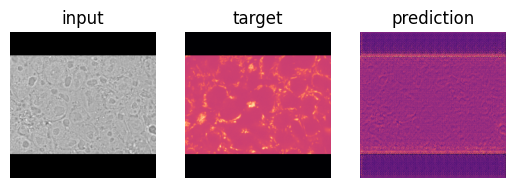

In [40]:
x, t = next(iter(dataloader_train))
with torch.no_grad():
    that = net(x.to(device))

plt.subplot(131); plt.imshow(x[0].squeeze(), cmap='gray'); plt.title('input');   plt.axis('off')
plt.subplot(132); plt.imshow(t[0].squeeze(), cmap='magma'); plt.title('target'); plt.axis('off')
plt.subplot(133); plt.imshow(that[0].cpu().squeeze(), cmap='magma'); plt.title('prediction'); plt.axis('off')
plt.show()

In [60]:
def _weights_init(m):
    classname = m.__class__.__name__
    if classname.startswith('Conv'):
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

net = UNet().to(device)
net.apply(_weights_init)

UNet(
  (downconv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (downconv2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (downconv3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (downconv4): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (upconv1): Sequential(
    (0): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [ ]:
def unpad_to_aspect(img, orig_shape=(624, 924), size=256):
    """
    Remove the symmetric zero-padding added by resize_pad_volume, recovering
    the resized (aspect-ratio-preserving) region.

    img        : (H, W) padded image (size x size)
    orig_shape : (y, x) spatial shape of the ORIGINAL volume before resize+pad
    returns    : cropped (new_y, new_x) image with padding removed
    """
    y, x = orig_shape
    scale = size / max(y, x)
    new_y = max(1, round(y * scale))
    new_x = max(1, round(x * scale))

    pad_y = size - new_y
    pad_x = size - new_x
    y0, x0 = pad_y // 2, pad_x // 2
    return img[y0:y0 + new_y, x0:x0 + new_x]

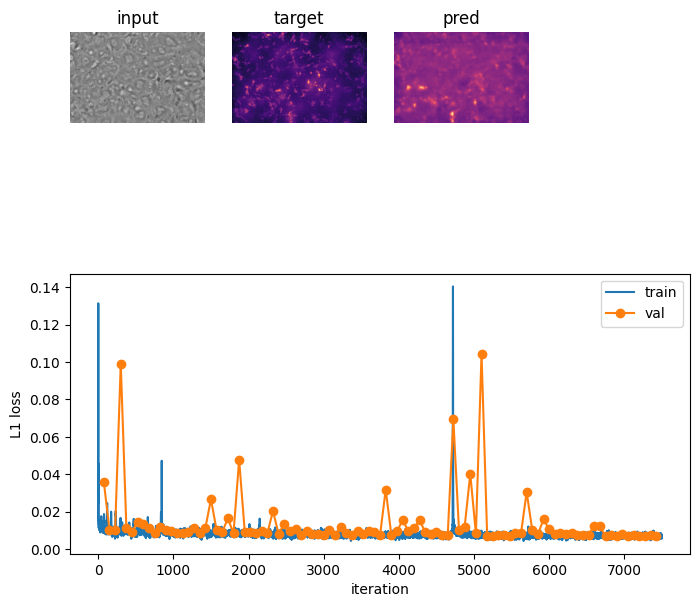

epoch 100/100  val L1 = 0.0074


In [62]:
import os

# supervised training: input -> target
optimizer = torch.optim.Adam(net.parameters(), lr=0.001, betas=(0.5, 0.999))
loss_fn = nn.MSELoss()

loss_train_vec = []
loss_val_vec   = []

# ---- best-weight saving config ----
save_dir = "/content/drive/MyDrive/Shraddha-Project/checkpoints"
os.makedirs(save_dir, exist_ok=True)
ckpt_path = os.path.join(save_dir, "unet_best.pt")
best_val = float('inf')

n_epochs = 100
i_iter = 0
for epoch in range(n_epochs):
    net.train()
    for data, label in dataloader_train:
        x = data.to(device)
        t = label.to(device)
        that = net(x)

        # compare prediction with target
        loss = loss_fn(that, t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_train_vec += [loss.item()]
        i_iter += 1

        if i_iter % 50 == 0:
            clear_output(wait=True)
            plt.figure(figsize=[8, 8])
            plt.subplot(241); plt.imshow(unpad_to_aspect(x[0].detach().cpu().squeeze()), cmap='gray');   plt.title('input');  plt.axis('off')
            plt.subplot(242); plt.imshow(unpad_to_aspect(t[0].detach().cpu().squeeze()), cmap='magma');     plt.title('target'); plt.axis('off')
            plt.subplot(243); plt.imshow(unpad_to_aspect(that[0].detach().cpu().squeeze()), cmap='magma');  plt.title('pred');   plt.axis('off')
            plt.subplot(212)
            plt.plot(loss_train_vec, label='train')
            if loss_val_vec:
                # plot val points at their iteration positions
                xs = [p[0] for p in loss_val_vec]; ys = [p[1] for p in loss_val_vec]
                plt.plot(xs, ys, 'o-', label='val')
            plt.legend(); plt.xlabel('iteration'); plt.ylabel('L1 loss')
            plt.show()

    # ---- validation pass ----
    net.eval()
    val_losses = []
    with torch.no_grad():
        for data, label in dataloader_val:
            x = data.to(device); t = label.to(device)
            val_losses.append(loss_fn(net(x), t).item())
    val_loss = float(np.mean(val_losses))
    loss_val_vec.append((i_iter, val_loss))
    print(f"epoch {epoch+1}/{n_epochs}  val L1 = {val_loss:.4f}")

    # ---- save best weights to disk ----
    if val_loss < best_val:
        best_val = val_loss
        torch.save(net.state_dict(), ckpt_path)
        print(f"  -> new best (val {best_val:.4f}), saved to {ckpt_path}")

In [65]:
# comparison metrics, single image at a time
from skimage.metrics import structural_similarity

def MSE(x, xhat):
    return np.mean((x - xhat) ** 2)

def MAE(x, xhat):
    return np.mean(np.abs(x - xhat))

def Pearson(x, y):
    xbar = np.mean(x)
    ybar = np.mean(y)
    return np.sum((x - xbar) * (y - ybar)) / (
        np.sqrt(np.sum((x - xbar) ** 2)) * np.sqrt(np.sum((y - ybar) ** 2)))

def PSNR(x, xhat):
    # data_range = max - min of the reference image (works for z-scored data too)
    data_range = x.max() - x.min()
    mse = MSE(x, xhat)
    return 10 * np.log10((data_range ** 2) / mse)

def SSIM(x, xhat):
    data_range = x.max() - x.min()
    return structural_similarity(x, xhat, data_range=data_range)

method 	 MSE 	 MAE 	Pearson	 SSIM 	 PSNR (dB)
Neural 	 0.002 	 0.034 	 0.577 	 0.645 	 23.793
x_np shape:  (173, 256)
t_np shape:  (173, 256)
that_np shape:  (173, 256)


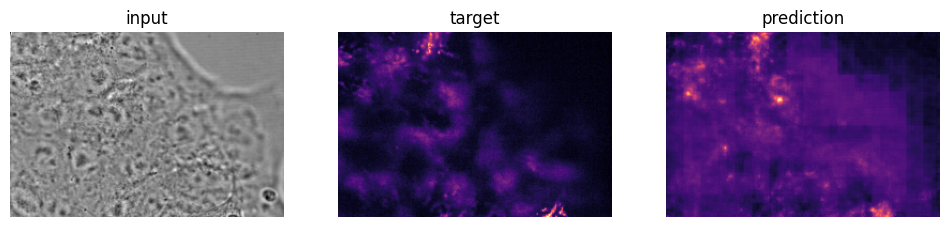

In [67]:
net.eval()
x, t = next(iter(dataloader_val))
with torch.no_grad():
    that = net(x.to(device))

x_np    = x[0].cpu().numpy().squeeze()
t_np    = t[0].cpu().numpy().squeeze()
that_np = that[0].cpu().numpy().squeeze()

# original (Y, X) for this sample — from ds.index entry (path, z, Y, X)
x_np    = unpad_to_aspect(x_np)
t_np    = unpad_to_aspect(t_np)
that_np = unpad_to_aspect(that_np)

# metrics on the unpadded region only
print('method \t MSE \t MAE \tPearson\t SSIM \t PSNR (dB)')
print(f'Neural \t {MSE(t_np, that_np):0.3f} \t {MAE(t_np, that_np):0.3f} \t '
      f'{Pearson(t_np, that_np):0.3f} \t {SSIM(t_np, that_np):0.3f} \t '
      f'{PSNR(t_np, that_np):0.3f}')
print("x_np shape: ", x_np.shape)
print("t_np shape: ", t_np.shape)
print("that_np shape: ", that_np.shape)

plt.figure(figsize=[12, 4])
plt.subplot(131); plt.imshow(x_np, cmap='gray');    plt.axis('off'); plt.title('input')
plt.subplot(132); plt.imshow(t_np, cmap='magma');   plt.axis('off'); plt.title('target')
plt.subplot(133); plt.imshow(that_np, cmap='magma'); plt.axis('off'); plt.title('prediction')
plt.show()